# Combined VLE + SEC IFT Notebook
This notebook combines:
1. **VLE_IFT_saturation**: cDFT-based IFT at bubble/dew points (planar interface)
2. **SEC_SATURATION_IFT**: Semi-empirical correlation IFT along saturation lines (Parachor & WSD)

All results are plotted together for comparison.

In [1]:
import time
notebook_start = time.perf_counter()

%pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift

import os
import numpy as np
import pandas as pd
import feos
import si_units as si
import matplotlib.pyplot as plt
import importlib.metadata
from pathlib import Path

from thermoift import KIJ
from thermoift.FeosPlugin import (
    RegistryManager,
    ParameterBuilder,
    PropertyCalculator,
    VLECalculator,
    InterfacialTensionCalculator,
    DataProcessor,
    PlottingEngine,
    PARAMETERS,
)
from thermoift.semi_emperical_correlations import semi_emperical_correlations
import thermoift.PLOT_SETTINGS as ps

print(f"FEOS version used: {importlib.metadata.version('feos')}")
KIJ_DIR = Path(KIJ.__file__).parent

Obtaining file:///home/darshan/A6/PCSAFT_cDFT/thermoift
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for thermoift (pyproject.toml) ... done
  Created wheel for thermoift: filename=thermoift-0.2.0-0.editable-py3-none-any.whl size=1730 sha256=bc26c58dbf3f51289ad0ed7a6c452772dd638ae9c35f471484efefcbeb74bede
  Stored in directory: /tmp/pip-ephem-wheel-cache-uhcixv29/wheels/fd/2f/c4/54a2ee5cd16a9bf5b183bbe5c28d1b3ba4926fb0261a13e1e4
Successfully built thermoift
  Attempting uninstall: thermoift
    Found existing installation: thermoift 0.2.0
    Uninstalling thermoift-0.2.0:
      Successfully uninstalled thermoift-0.2.0
Note: you may need to restart the kernel to use updated packages.
FEOS version used: 0.9.4


## Configuration

In [2]:
# --- Component & Feed Setup ---
COMPONENT_NAMES = ["carbon dioxide", "hydrogen", "argon"]
ALL_COMPONENTS  = ["carbon dioxide", "hydrogen", "argon", "nitrogen", "methane", "oxygen"]
FEED_Z          = np.array([0.95, 0.02, 0.03], dtype=float)
FEED_Z          = FEED_Z / FEED_Z.sum()

# --- KIJ setup ---
KIJ_map = {
    ("CO2", "Ar") : "constant",
    ("H2",  "Ar") : "constant",
    ("CO2", "H2") : "constant",
}

# --- Computation settings ---
T_initial   = 200       # Starting temperature [K]
T_STEP      = 1         # Temperature step [K]
P_TOL       = 1e-4      # Pressure tolerance for flash [bar]
N_POINTS    = 50        # Number of points for SEC saturation IFT (50=fast, 500=slow)
lgrid       = 100       # cDFT domain length [Angstrom]
ngrid       = 2048      # cDFT grid points
verbose     = True

CSV_FOLDER      = "CSV_combined"
Path(CSV_FOLDER).mkdir(parents=True, exist_ok=True)


K(300.0 K) =
[[0.         0.04278669 0.03481295]
 [0.04278669 0.         0.18117968]
 [0.03481295 0.18117968 0.        ]]

Symbolic K(T) matrix:


Matrix([
[     0, 0.0428, 0.0348],
[0.0428,      0, 0.1812],
[0.0348, 0.1812,      0]])


Pair equations:


Eq(k_{CO2,H2}(T), 0.0428)

Eq(k_{CO2,Ar}(T), 0.0348)

Eq(k_{H2,Ar}(T), 0.1812)

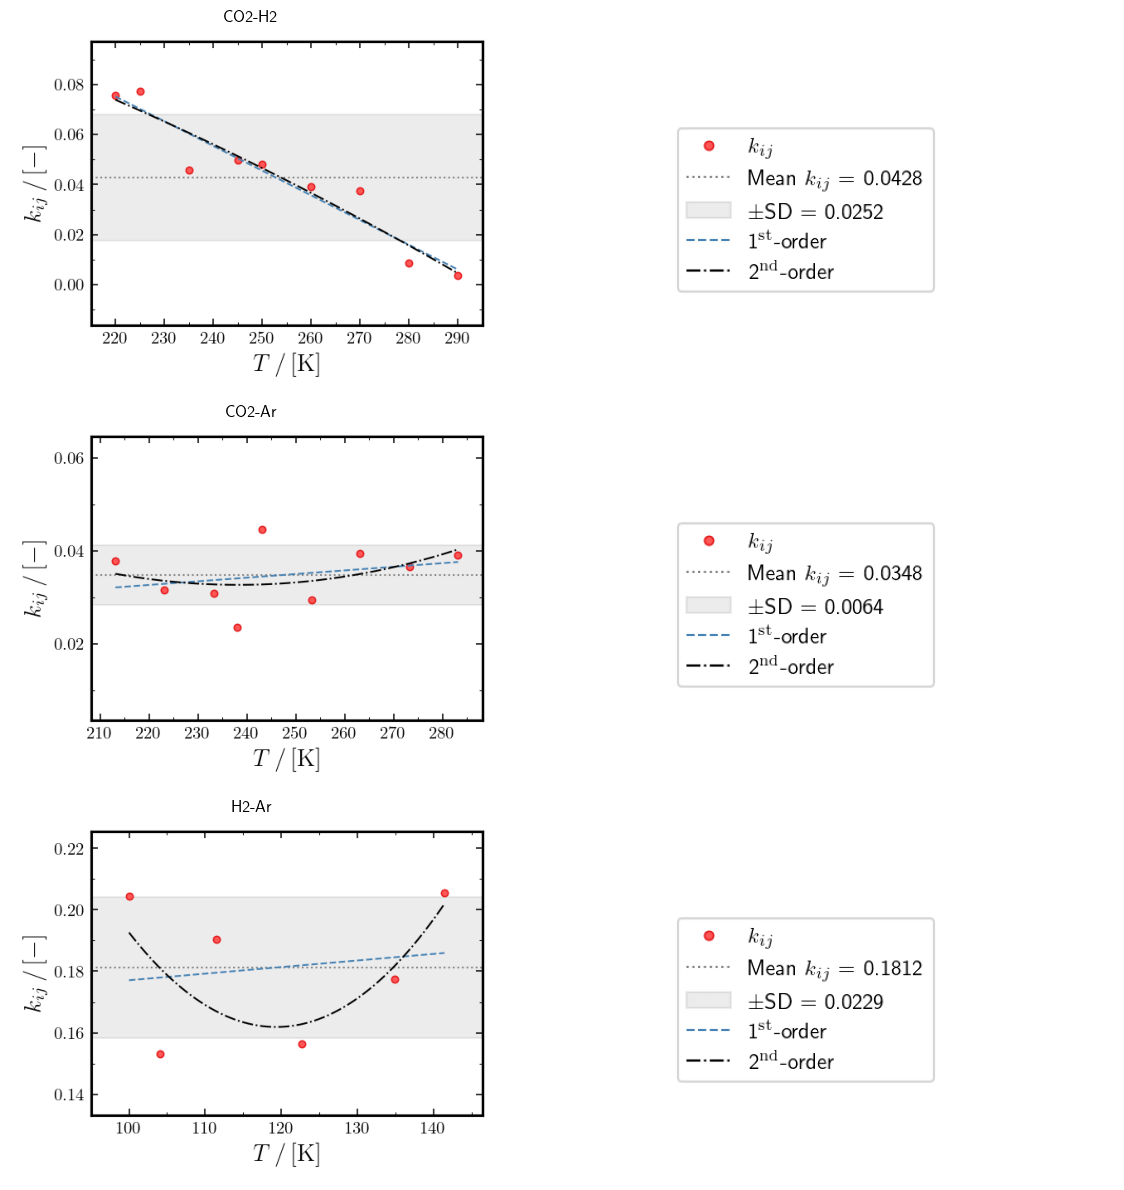

In [3]:
# --- KIJ builder & display ---
builder    = KIJ.KIJMatrixBuilder(root=str(KIJ_DIR), kij_filename="KIJ.json", verbose=False)
KIJ_LABELS = RegistryManager.kij_labels_from_names(COMPONENT_NAMES)

builder.build_and_display(
    components=KIJ_LABELS,
    model_map=KIJ_map,
    T_eval=300.0,
    show_matrix=True,
    show_pair_equations=True,
)
builder.show_pair_plots(KIJ_LABELS, mode="all")

## Phase Envelope (Bubble & Dew Curves)

In [4]:
# --- Critical point ---
params_ref = PARAMETERS(COMPONENT_NAMES, T_K=T_initial, kij_builder=builder, model_map=KIJ_map)
eos_ref    = feos.HelmholtzEnergyFunctional.pcsaft(params_ref)
feed_si    = FEED_Z * si.MOL

Tc_si, Pc_si = VLECalculator.compute_critical_point(eos_ref, FEED_Z, T_guess=T_initial)
Tc_K  = Tc_si / si.KELVIN
Pc_bar = Pc_si / si.BAR
print(f"Critical Point: T = {Tc_K:.2f} K, P = {Pc_bar:.2f} bar")

# --- Bubble and dew curves with T-dependent kij ---
T_values = range(int(T_initial), int(Tc_K) + 1, T_STEP)

T_bub, P_bub = [], []
T_dew, P_dew = [], []

for T_K_val in T_values:
    params_T = PARAMETERS(COMPONENT_NAMES, T_K=float(T_K_val), kij_builder=builder, model_map=KIJ_map)
    eos_T    = feos.HelmholtzEnergyFunctional.pcsaft(params_T)

    Tb, Pb = VLECalculator.compute_bubble_curve(eos_T, [T_K_val], feed_si, verbose=False)
    Td, Pd = VLECalculator.compute_dew_curve(eos_T,    [T_K_val], feed_si, verbose=False)

    T_bub.extend(Tb); P_bub.extend(Pb)
    T_dew.extend(Td); P_dew.extend(Pd)

print(f"Bubble points: {len(T_bub)}, Dew points: {len(T_dew)}")

Critical Point: T = 305.84 K, P = 92.00 bar
Bubble points: 103, Dew points: 104


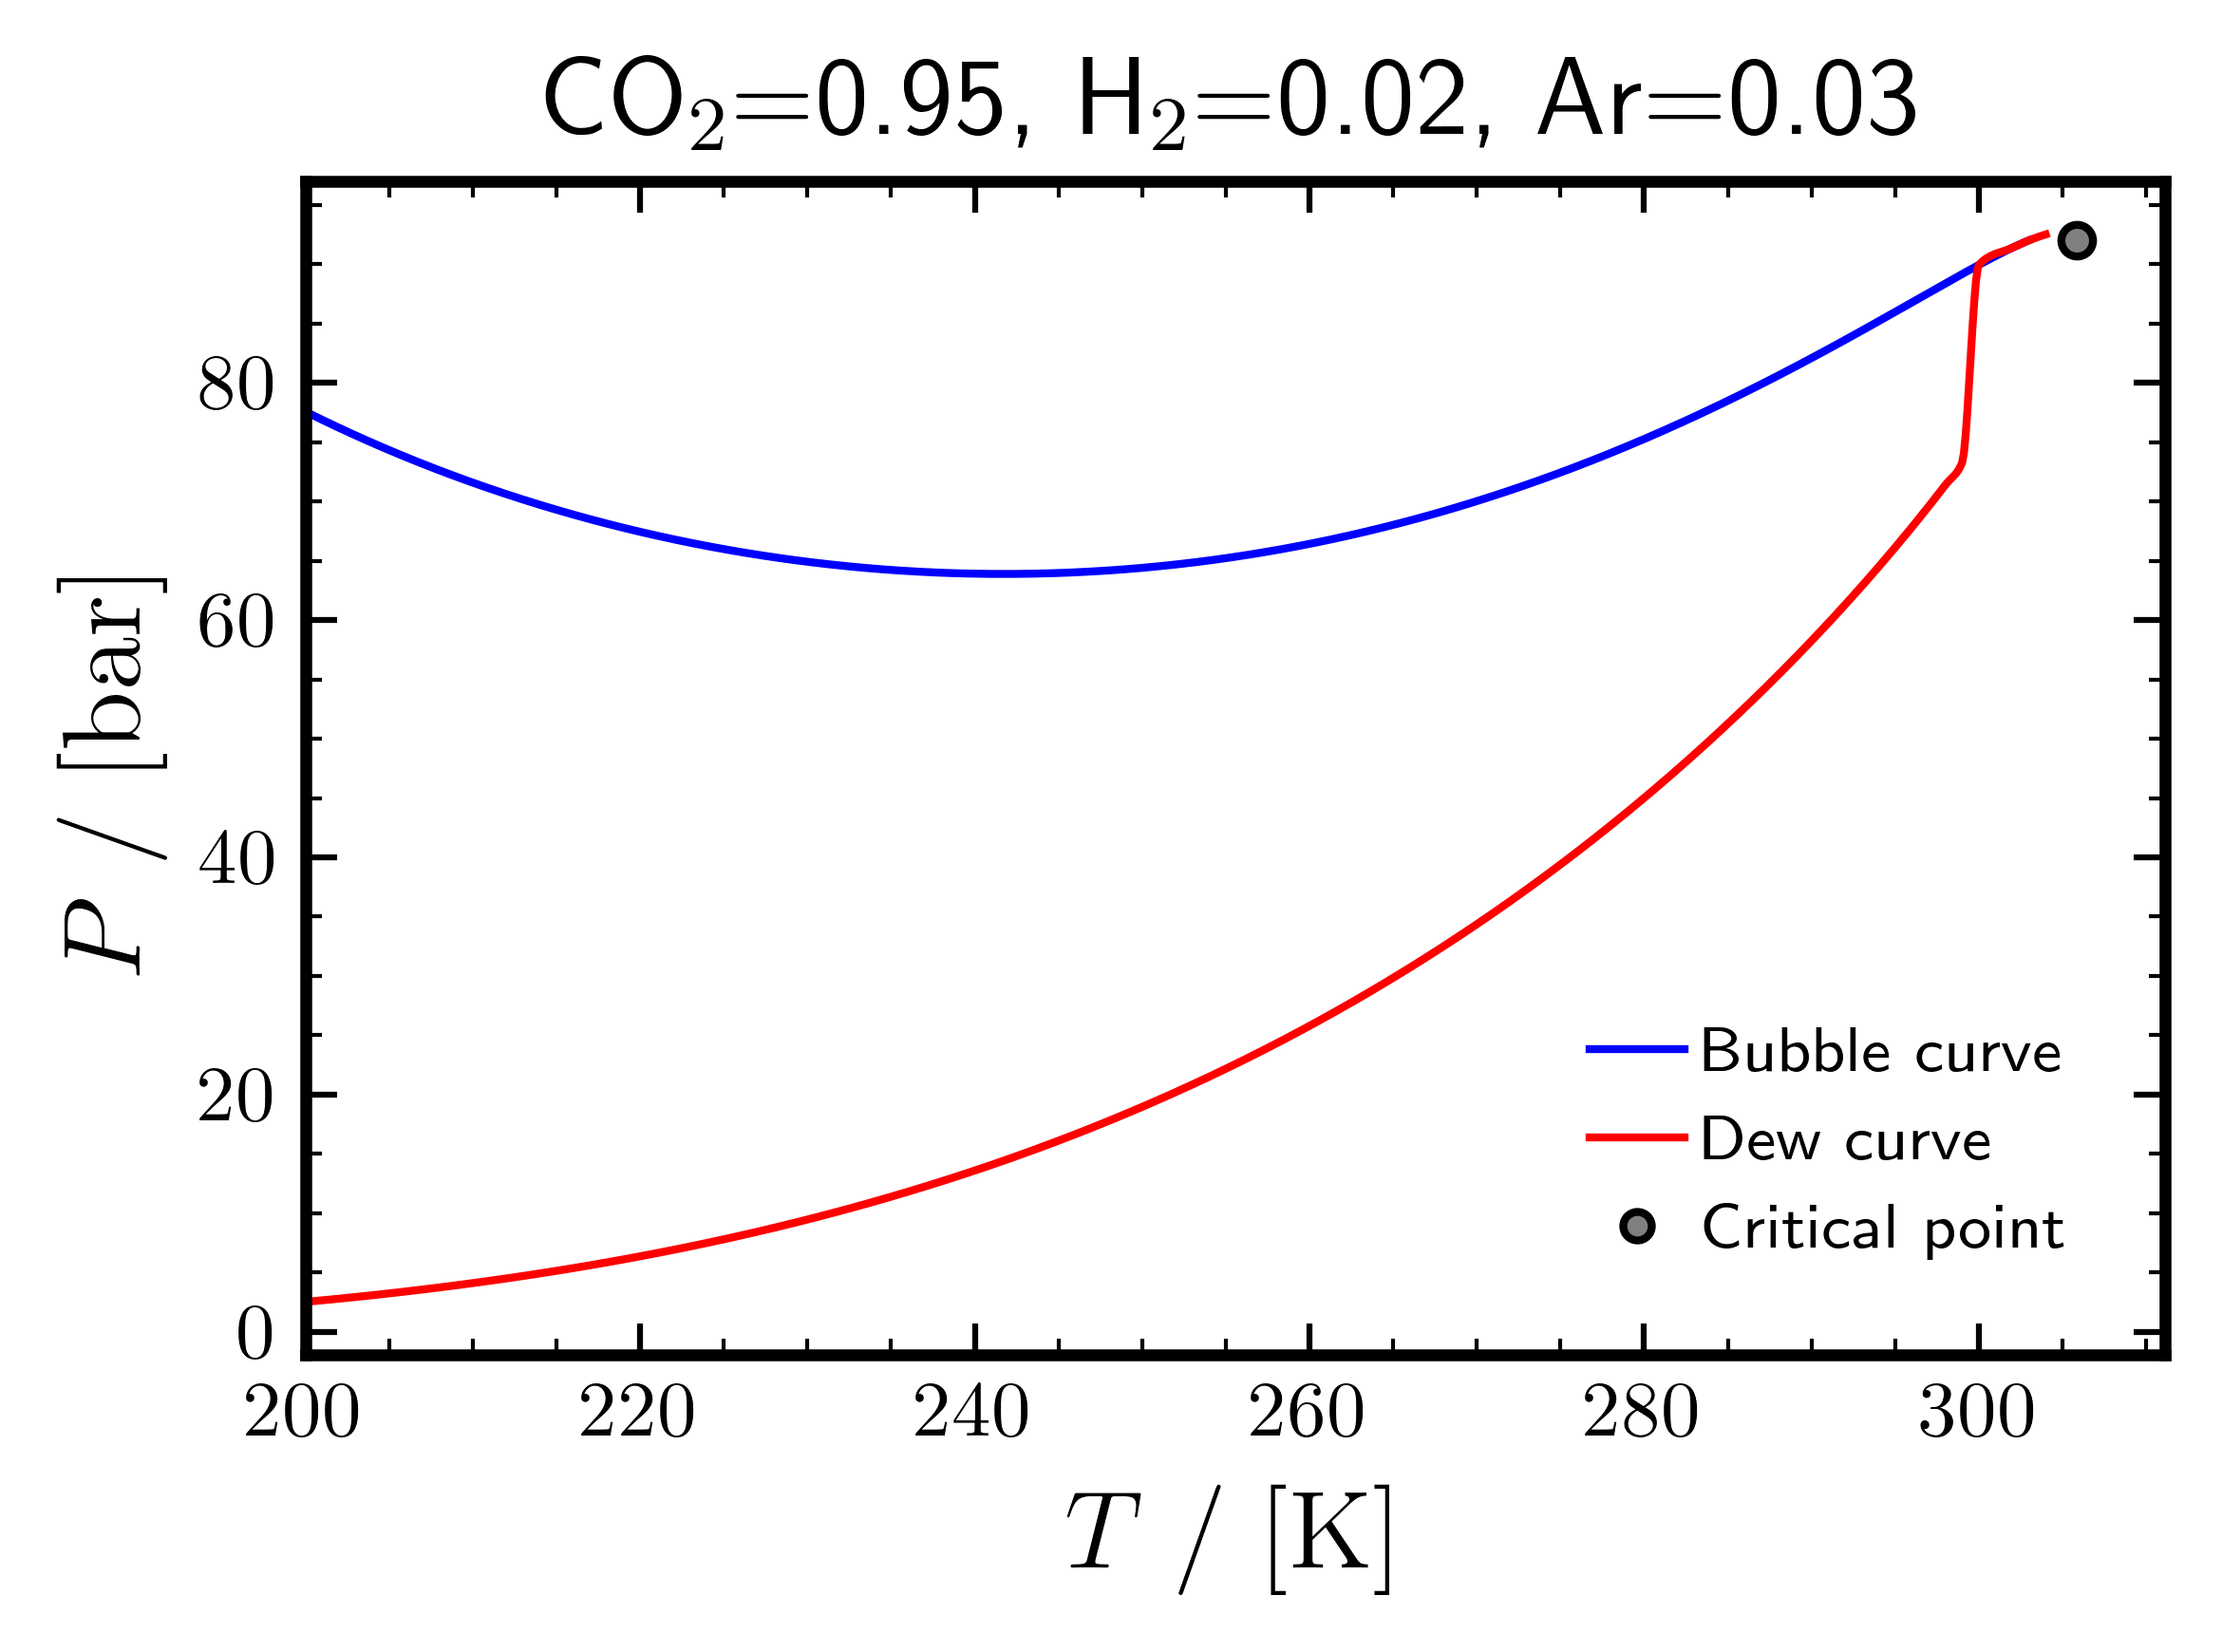

In [5]:
# --- Phase diagram plot ---
feed_key = "feed_1"
PT_results = {
    feed_key: {
        "bubble": [{"T_K": T, "P_bar": P} for T, P in zip(T_bub, P_bub)],
        "dew":    [{"T_K": T, "P_bar": P} for T, P in zip(T_dew, P_dew)],
        "TC_K":   Tc_K,
        "PC_bar": Pc_bar,
        "z":      FEED_Z,
    }
}

fig, ax = PlottingEngine.plot_phase_diagram(PT_results, feed_key, params_ref)
plt.show()

## Part 1: SEC IFT along Saturation Lines (Parachor & WSD)

In [6]:
# --- SEC: Parachor method ---
model = semi_emperical_correlations()

sat_data_parachor = model.compute_saturation_line_IFT(
    component_names=COMPONENT_NAMES,
    feed_z=FEED_Z,
    eos=eos_ref,
    T_bub=T_bub,
    P_bub=P_bub,
    T_dew=T_dew,
    P_dew=P_dew,
    method="parachor",
    n_exp=3.87,
    kij_parachor=0.0,
    recompute_parachor=True,
    line="both",
    n_points=N_POINTS,
    P_offset_frac=0.005,
    kij_builder=builder,
    model_map=KIJ_map,
)

# --- SEC: WSD method (corrected + uncorrected) ---
sat_data_wsd = model.compute_saturation_line_IFT(
    component_names=COMPONENT_NAMES,
    feed_z=FEED_Z,
    eos=eos_ref,
    T_bub=T_bub,
    P_bub=P_bub,
    T_dew=T_dew,
    P_dew=P_dew,
    method="wsd",
    phi_wsd=1.0,
    line="both",
    n_points=N_POINTS,
    P_offset_frac=0.005,
    kij_builder=builder,
    model_map=KIJ_map,
)

df_sat_parachor = semi_emperical_correlations.saturation_line_to_dataframe(
    sat_data_parachor, COMPONENT_NAMES, line="both")
df_sat_wsd = semi_emperical_correlations.saturation_line_to_dataframe(
    sat_data_wsd, COMPONENT_NAMES, line="both")

print(f"Parachor DataFrame shape: {df_sat_parachor.shape}")
print(f"WSD DataFrame shape: {df_sat_wsd.shape}")

/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:238: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=298.5052857142857 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:238: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=300.60114285714286 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:238: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=302.697 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:238: UserWarning: cDFT solve fa

Parachor DataFrame shape: (98, 40)
WSD DataFrame shape: (93, 40)


In [7]:
# --- Save SEC saturation DataFrames ---
dfs = semi_emperical_correlations.save_saturation_dataframes(
    df_sat_parachor, df_sat_wsd,
    output_dir=CSV_FOLDER,
    component_names=COMPONENT_NAMES,
    feed_z=FEED_Z,
    n_exp=3.87,
    ML_mode=True,
    all_components=ALL_COMPONENTS,
)

df_bubble_para = dfs["bubble_parachor"]
df_bubble_wsd  = dfs["bubble_wsd"]
df_dew_para    = dfs["dew_parachor"]
df_dew_wsd     = dfs["dew_wsd"]

print(f"\nBubble Parachor columns: {list(df_bubble_para.columns)}")
print(f"\nBubble WSD columns: {list(df_bubble_wsd.columns)}")

Saved CSV_combined/bubble_parachor.csv (50 rows, 36 cols)
Saved CSV_combined/bubble_wsd.csv (47 rows, 42 cols)
Saved CSV_combined/dew_parachor.csv (48 rows, 36 cols)
Saved CSV_combined/dew_wsd.csv (46 rows, 42 cols)

Bubble Parachor columns: ['T', 'P', 'z_carbon dioxide', 'z_hydrogen', 'z_argon', 'z_nitrogen', 'z_methane', 'z_oxygen', 'rho_l', 'rho_v', 'x_carbon dioxide', 'x_hydrogen', 'x_argon', 'x_nitrogen', 'x_methane', 'x_oxygen', 'y_carbon dioxide', 'y_hydrogen', 'y_argon', 'y_nitrogen', 'y_methane', 'y_oxygen', 'gamma0_carbon dioxide', 'rhoL0_carbon dioxide', 'rhoV0_carbon dioxide', 'Tc_carbon dioxide', 'Pc_carbon dioxide', 'Psat0_carbon dioxide', 'parachor_carbon dioxide', 'parachor_hydrogen', 'parachor_argon', 'parachor_nitrogen', 'parachor_methane', 'parachor_oxygen', 'n_exp', 'gamma_parachor']

Bubble WSD columns: ['T', 'P', 'z_carbon dioxide', 'z_hydrogen', 'z_argon', 'z_nitrogen', 'z_methane', 'z_oxygen', 'rho_l', 'rho_v', 'x_carbon dioxide', 'x_hydrogen', 'x_argon', 'x_nit

## Part 2: cDFT IFT at Bubble & Dew Points (Planar Interface)

In [8]:
# --- cDFT IFT at bubble and dew points ---
sec = semi_emperical_correlations(n_grid=ngrid, l_grid=lgrid)

# Build bubble/dew lookup dicts
bub_dict = {int(round(T)): float(P) for T, P in zip(T_bub, P_bub)}
dew_dict = {int(round(T)): float(P) for T, P in zip(T_dew, P_dew)}
common_T = sorted(set(bub_dict) & set(dew_dict))

VLE_DFT_boundary = {
    "z": FEED_Z.tolist(),
    "bubble_point_IFT": [],
    "dew_point_IFT": [],
}

CT = Tc_K * si.KELVIN
CP = Pc_bar * si.BAR

print(f"Computing cDFT IFT at {len(common_T)} common bubble/dew temperatures...")

for T in common_T:
    # Rebuild parameters and eos at this temperature
    params_T = ParameterBuilder.build_parameters(
        COMPONENT_NAMES, T_K=float(T), kij_builder=builder, model_map=KIJ_map
    )
    eos_T = feos.HelmholtzEnergyFunctional.pcsaft(params_T)
    molar_masses = PropertyCalculator.molar_masses(params_T)

    # Pure CO2 properties at this temperature
    gamma0_CO2, rhoL0_CO2, rhoV0_CO2, Tc_CO2, Pc_CO2, Psat_CO2 = \
        sec._pure_component_cDFT("carbon dioxide", float(T))

    P_b = bub_dict[T]
    P_d = dew_dict[T]

    if P_b < P_d:
        continue

    for point_type, P in [("bubble", P_b - P_TOL), ("dew", P_d + P_TOL)]:
        if verbose:
            print(f"T = {T} K | {point_type} point | P_flash = {P:.4f} bar")

        # TP flash
        try:
            eq, x, y, liquid_density, vapor_density = VLECalculator.tp_flash(
                eos_T, T * si.KELVIN, P * si.BAR, FEED_Z * si.MOL, molar_masses
            )
        except Exception as e:
            print(f"  TP flash failed at {point_type}: T={T} K, P={P:.4f} bar: {e}")
            continue

        # Planar interface & surface tension
        interface = InterfacialTensionCalculator.build_planar_interface(
            eq, critical_temperature=CT, n_grid=ngrid, l_grid=lgrid
        )

        try:
            gamma_mN_m, interfacial_thickness_nm, enrichment = \
                InterfacialTensionCalculator.solve_interface_properties(interface)
        except Exception as e:
            print(f"  IFT failed at {point_type}: T={T} K, P={P:.4f} bar: {e}")
            gamma_mN_m = np.nan
            interfacial_thickness_nm = np.nan
            enrichment = tuple(np.nan for _ in COMPONENT_NAMES)

        row_data = DataProcessor.assemble_row(
            T, P, FEED_Z, CT, CP, P_b, P_d, liquid_density, vapor_density,
            x, y, gamma_mN_m, interfacial_thickness_nm, COMPONENT_NAMES, enrichment,
            gamma0_CO2=gamma0_CO2,
            rhoL0_CO2_mol_cm3=rhoL0_CO2,
            rhoV0_CO2_mol_cm3=rhoV0_CO2,
            Tc_CO2=Tc_CO2,
            Psat_CO2=Psat_CO2,
            ML_mode=False,
        )

        VLE_DFT_boundary[f"{point_type}_point_IFT"].append(row_data)
        print(f"  T = {T} K | {point_type:6s} | P = {P:.4f} bar | gamma = {gamma_mN_m:.4f} mN/m")

# Save cDFT CSVs
for point_type in ["bubble_point_IFT", "dew_point_IFT"]:
    if VLE_DFT_boundary[point_type]:
        df = pd.DataFrame(VLE_DFT_boundary[point_type])
        filename = f"{CSV_FOLDER}/{feed_key}_{point_type}.csv"
        df.to_csv(filename, index=False)
        print(f"Saved {filename} ({len(df)} rows)")

# Load cDFT results for plotting
df_cDFT_bubble = pd.DataFrame(VLE_DFT_boundary["bubble_point_IFT"]) if VLE_DFT_boundary["bubble_point_IFT"] else pd.DataFrame()
df_cDFT_dew    = pd.DataFrame(VLE_DFT_boundary["dew_point_IFT"])    if VLE_DFT_boundary["dew_point_IFT"]    else pd.DataFrame()

Computing cDFT IFT at 102 common bubble/dew temperatures...
T = 200 K | bubble point | P_flash = 77.5769 bar
  T = 200 K | bubble | P = 77.5769 bar | gamma = 14.1788 mN/m
T = 200 K | dew point | P_flash = 2.5237 bar
  T = 200 K | dew    | P = 2.5237 bar | gamma = 19.8878 mN/m
T = 201 K | bubble point | P_flash = 76.8846 bar
  T = 201 K | bubble | P = 76.8846 bar | gamma = 14.0485 mN/m
T = 201 K | dew point | P_flash = 2.6563 bar
  T = 201 K | dew    | P = 2.6563 bar | gamma = 19.6507 mN/m
T = 202 K | bubble point | P_flash = 76.2143 bar
  T = 202 K | bubble | P = 76.2143 bar | gamma = 13.9166 mN/m
T = 202 K | dew point | P_flash = 2.7942 bar
  T = 202 K | dew    | P = 2.7942 bar | gamma = 19.4140 mN/m
T = 203 K | bubble point | P_flash = 75.5655 bar
  T = 203 K | bubble | P = 75.5655 bar | gamma = 13.7830 mN/m
T = 203 K | dew point | P_flash = 2.9377 bar
  T = 203 K | dew    | P = 2.9377 bar | gamma = 19.1779 mN/m
T = 204 K | bubble point | P_flash = 74.9376 bar
  T = 204 K | bubble | 

/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:238: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=298.0 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(


T = 298 K | bubble point | P_flash = 88.3794 bar
  IFT failed at bubble: T=298 K, P=88.3794 bar: `DFT` did not converge within the maximum number of iterations.
  T = 298 K | bubble | P = 88.3794 bar | gamma = nan mN/m
T = 298 K | dew point | P_flash = 71.3928 bar
  T = 298 K | dew    | P = 71.3928 bar | gamma = 0.6713 mN/m
T = 299 K | bubble point | P_flash = 89.1686 bar
  IFT failed at bubble: T=299 K, P=89.1686 bar: `DFT` did not converge within the maximum number of iterations.
  T = 299 K | bubble | P = 89.1686 bar | gamma = nan mN/m
T = 299 K | dew point | P_flash = 73.2620 bar
  IFT failed at dew: T=299 K, P=73.2620 bar: `DFT` did not converge within the maximum number of iterations.
  T = 299 K | dew    | P = 73.2620 bar | gamma = nan mN/m


/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:238: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=300.0 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:238: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=302.0 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(


T = 302 K | bubble point | P_flash = 91.3896 bar
  T = 302 K | bubble | P = 91.3896 bar | gamma = 0.1055 mN/m
T = 302 K | dew point | P_flash = 91.3898 bar
  TP flash failed at dew: T=302 K, P=91.3898 bar: No phase split according to stability analysis.
Saved CSV_combined/feed_1_bubble_point_IFT.csv (100 rows)
Saved CSV_combined/feed_1_dew_point_IFT.csv (99 rows)


/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:238: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=303.0 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(


## Combined Plots: cDFT + Parachor + WSD

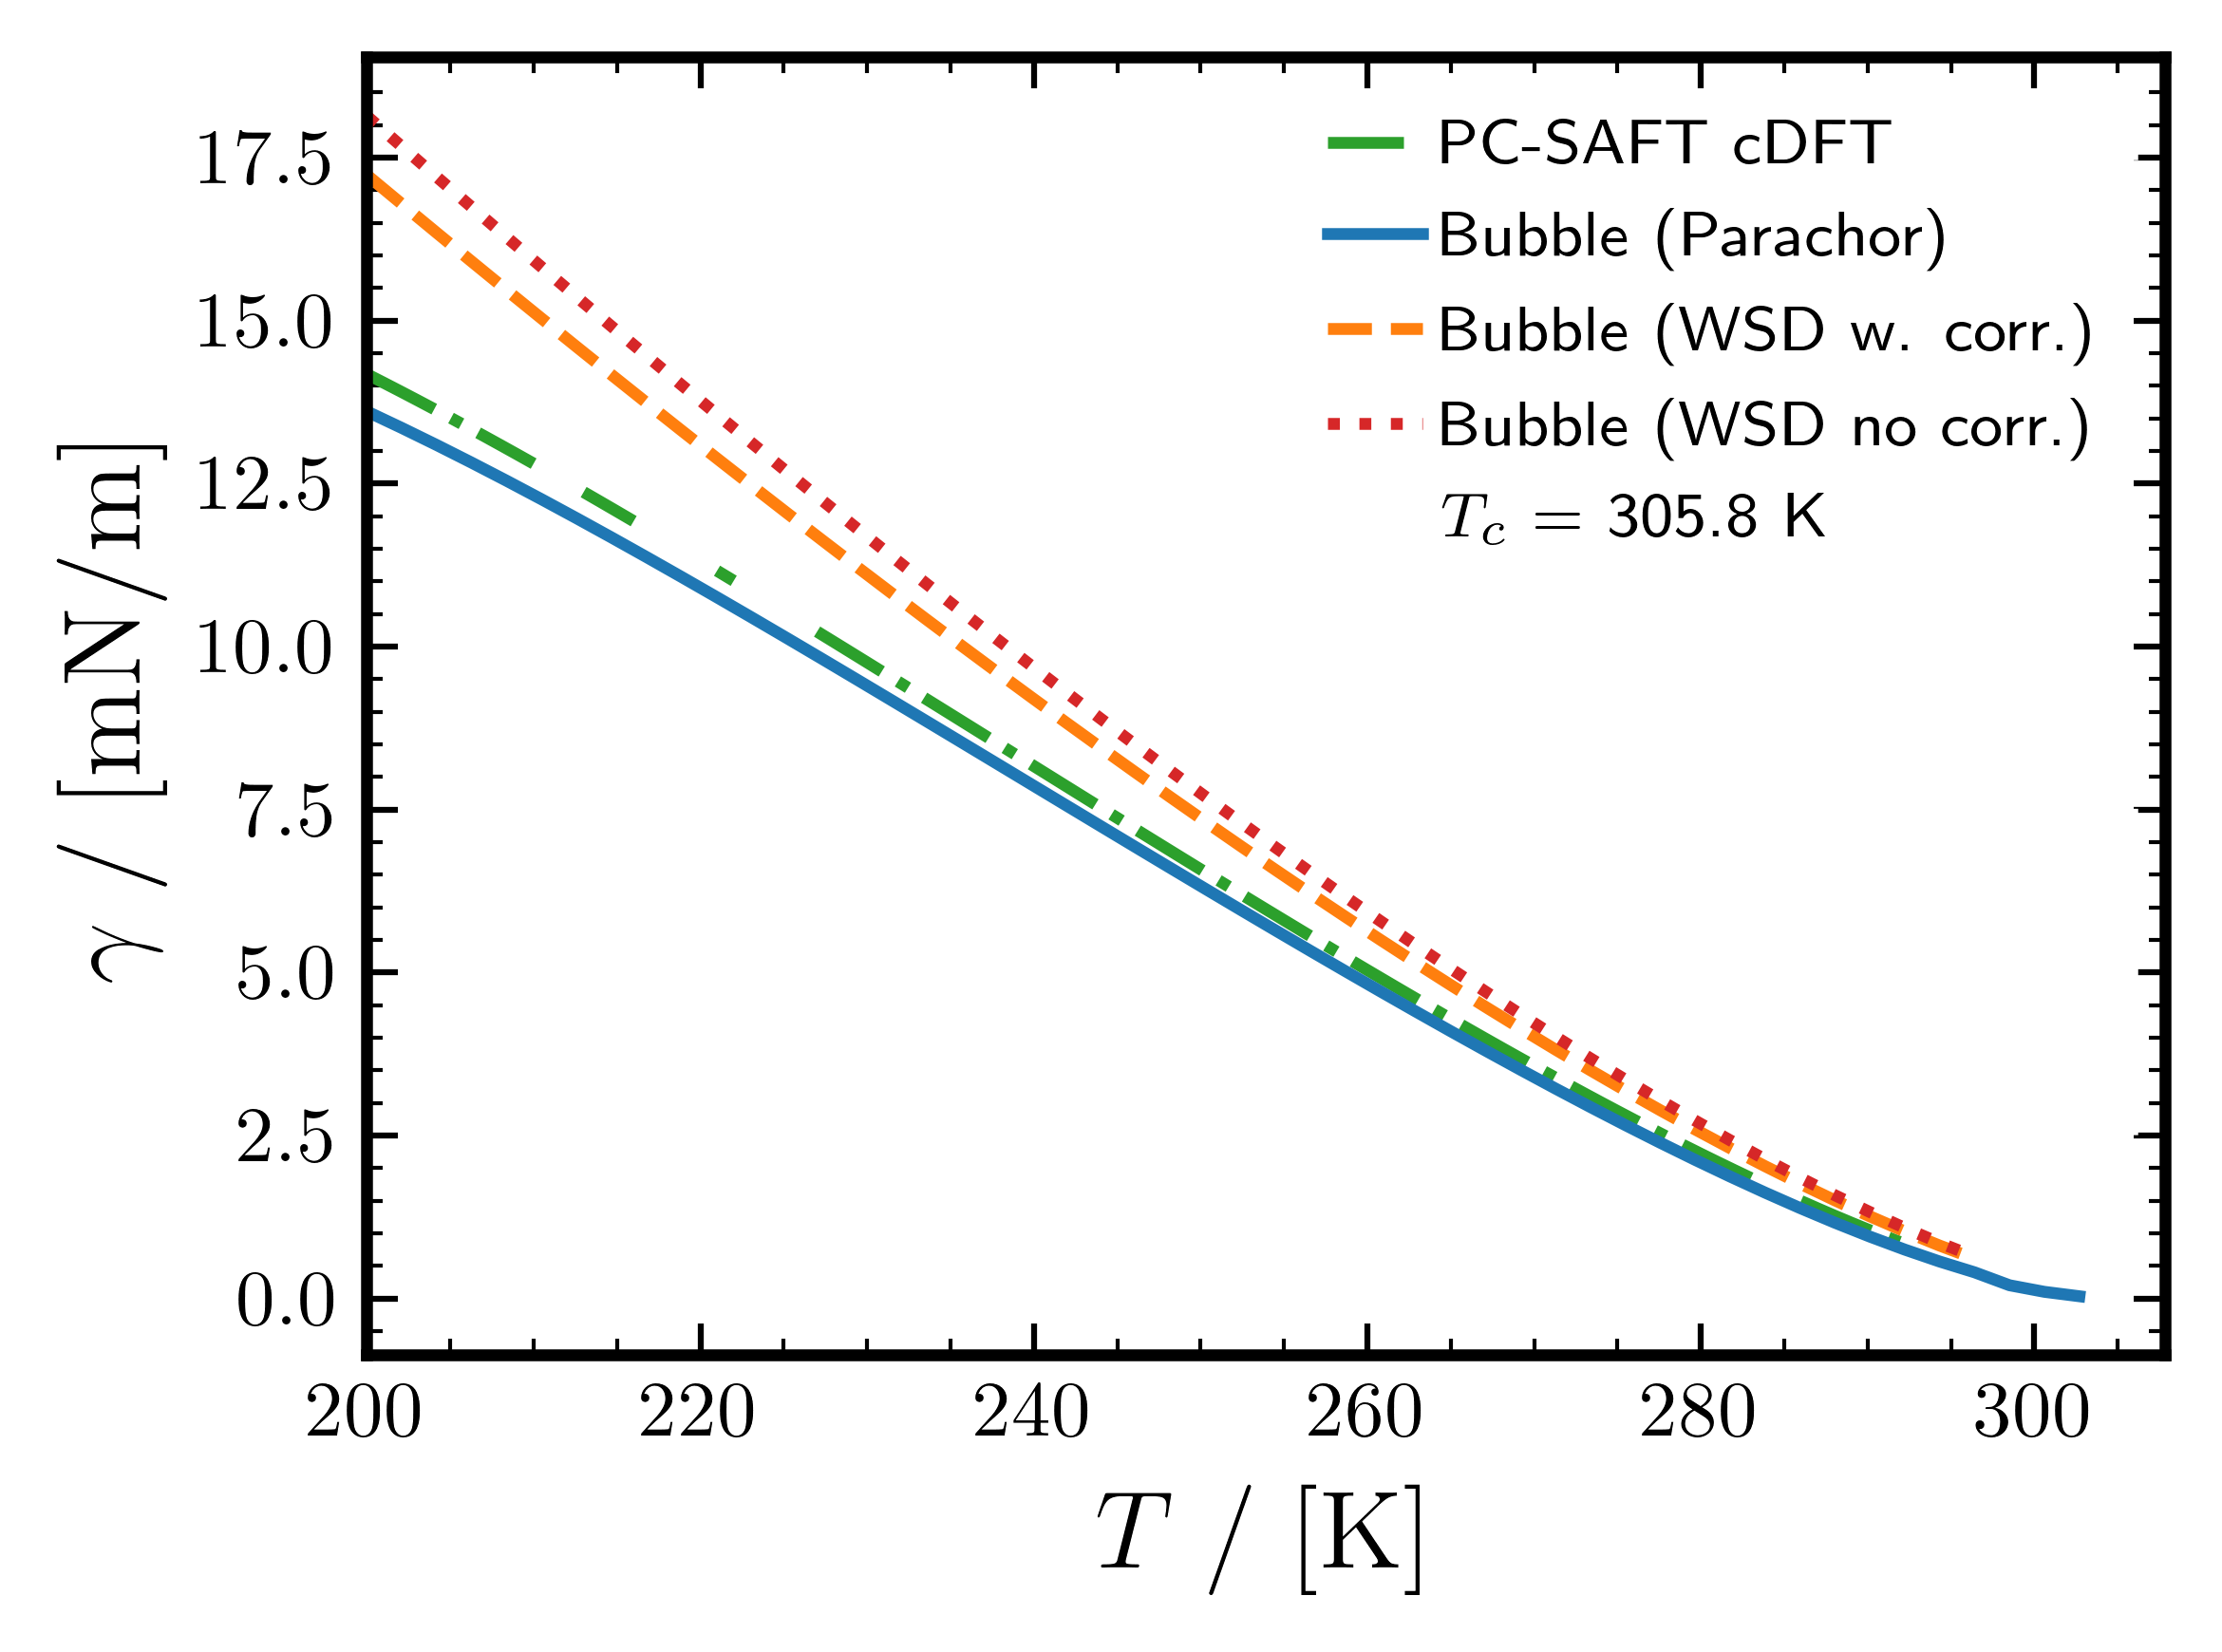

Bubble IFT plot saved to CSV_combined/bubble_IFT_vs_T.png


In [9]:
# --- Bubble IFT vs Temperature (all methods) ---

fig, ax = ps.plot_init()

# PC-SAFT cDFT (planar interface)
if not df_cDFT_bubble.empty:
    ax.plot(df_cDFT_bubble["temperature"], df_cDFT_bubble["gamma"],
            label="PC-SAFT cDFT", linestyle="-.", color="C2")

# Parachor
if not df_bubble_para.empty:
    ax.plot(df_bubble_para["T"], df_bubble_para["gamma_parachor"],
            "-", label="Bubble (Parachor)", color="C0")

# WSD
if not df_bubble_wsd.empty:
    ax.plot(df_bubble_wsd["T"], df_bubble_wsd["gamma_wsd_corrected"],
            "--", label="Bubble (WSD w. corr.)", color="C1")
    ax.plot(df_bubble_wsd["T"], df_bubble_wsd["gamma_wsd"],
            ":", label="Bubble (WSD no corr.)", color="C3")

ax.axvline(Tc_K, color="w", linestyle=":", label=f"$T_c$ = {Tc_K:.1f} K")
ax.set_xlabel(r"$T \; / \; [\mathrm{K}]$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"$\gamma \; / \; [\mathrm{mN/m}]$", fontsize=ps.label_fontsize)
ax.set_xlim(left=200)
ax.minorticks_on()
ps.style_legend(ax, fontsize=ps.legend_fontsize, loc="best", framealpha=0)
plt.tight_layout()
plt.savefig(f"{CSV_FOLDER}/bubble_IFT_vs_T.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{CSV_FOLDER}/bubble_IFT_vs_T.pdf", bbox_inches="tight")
plt.show()
print(f"Bubble IFT plot saved to {CSV_FOLDER}/bubble_IFT_vs_T.png")

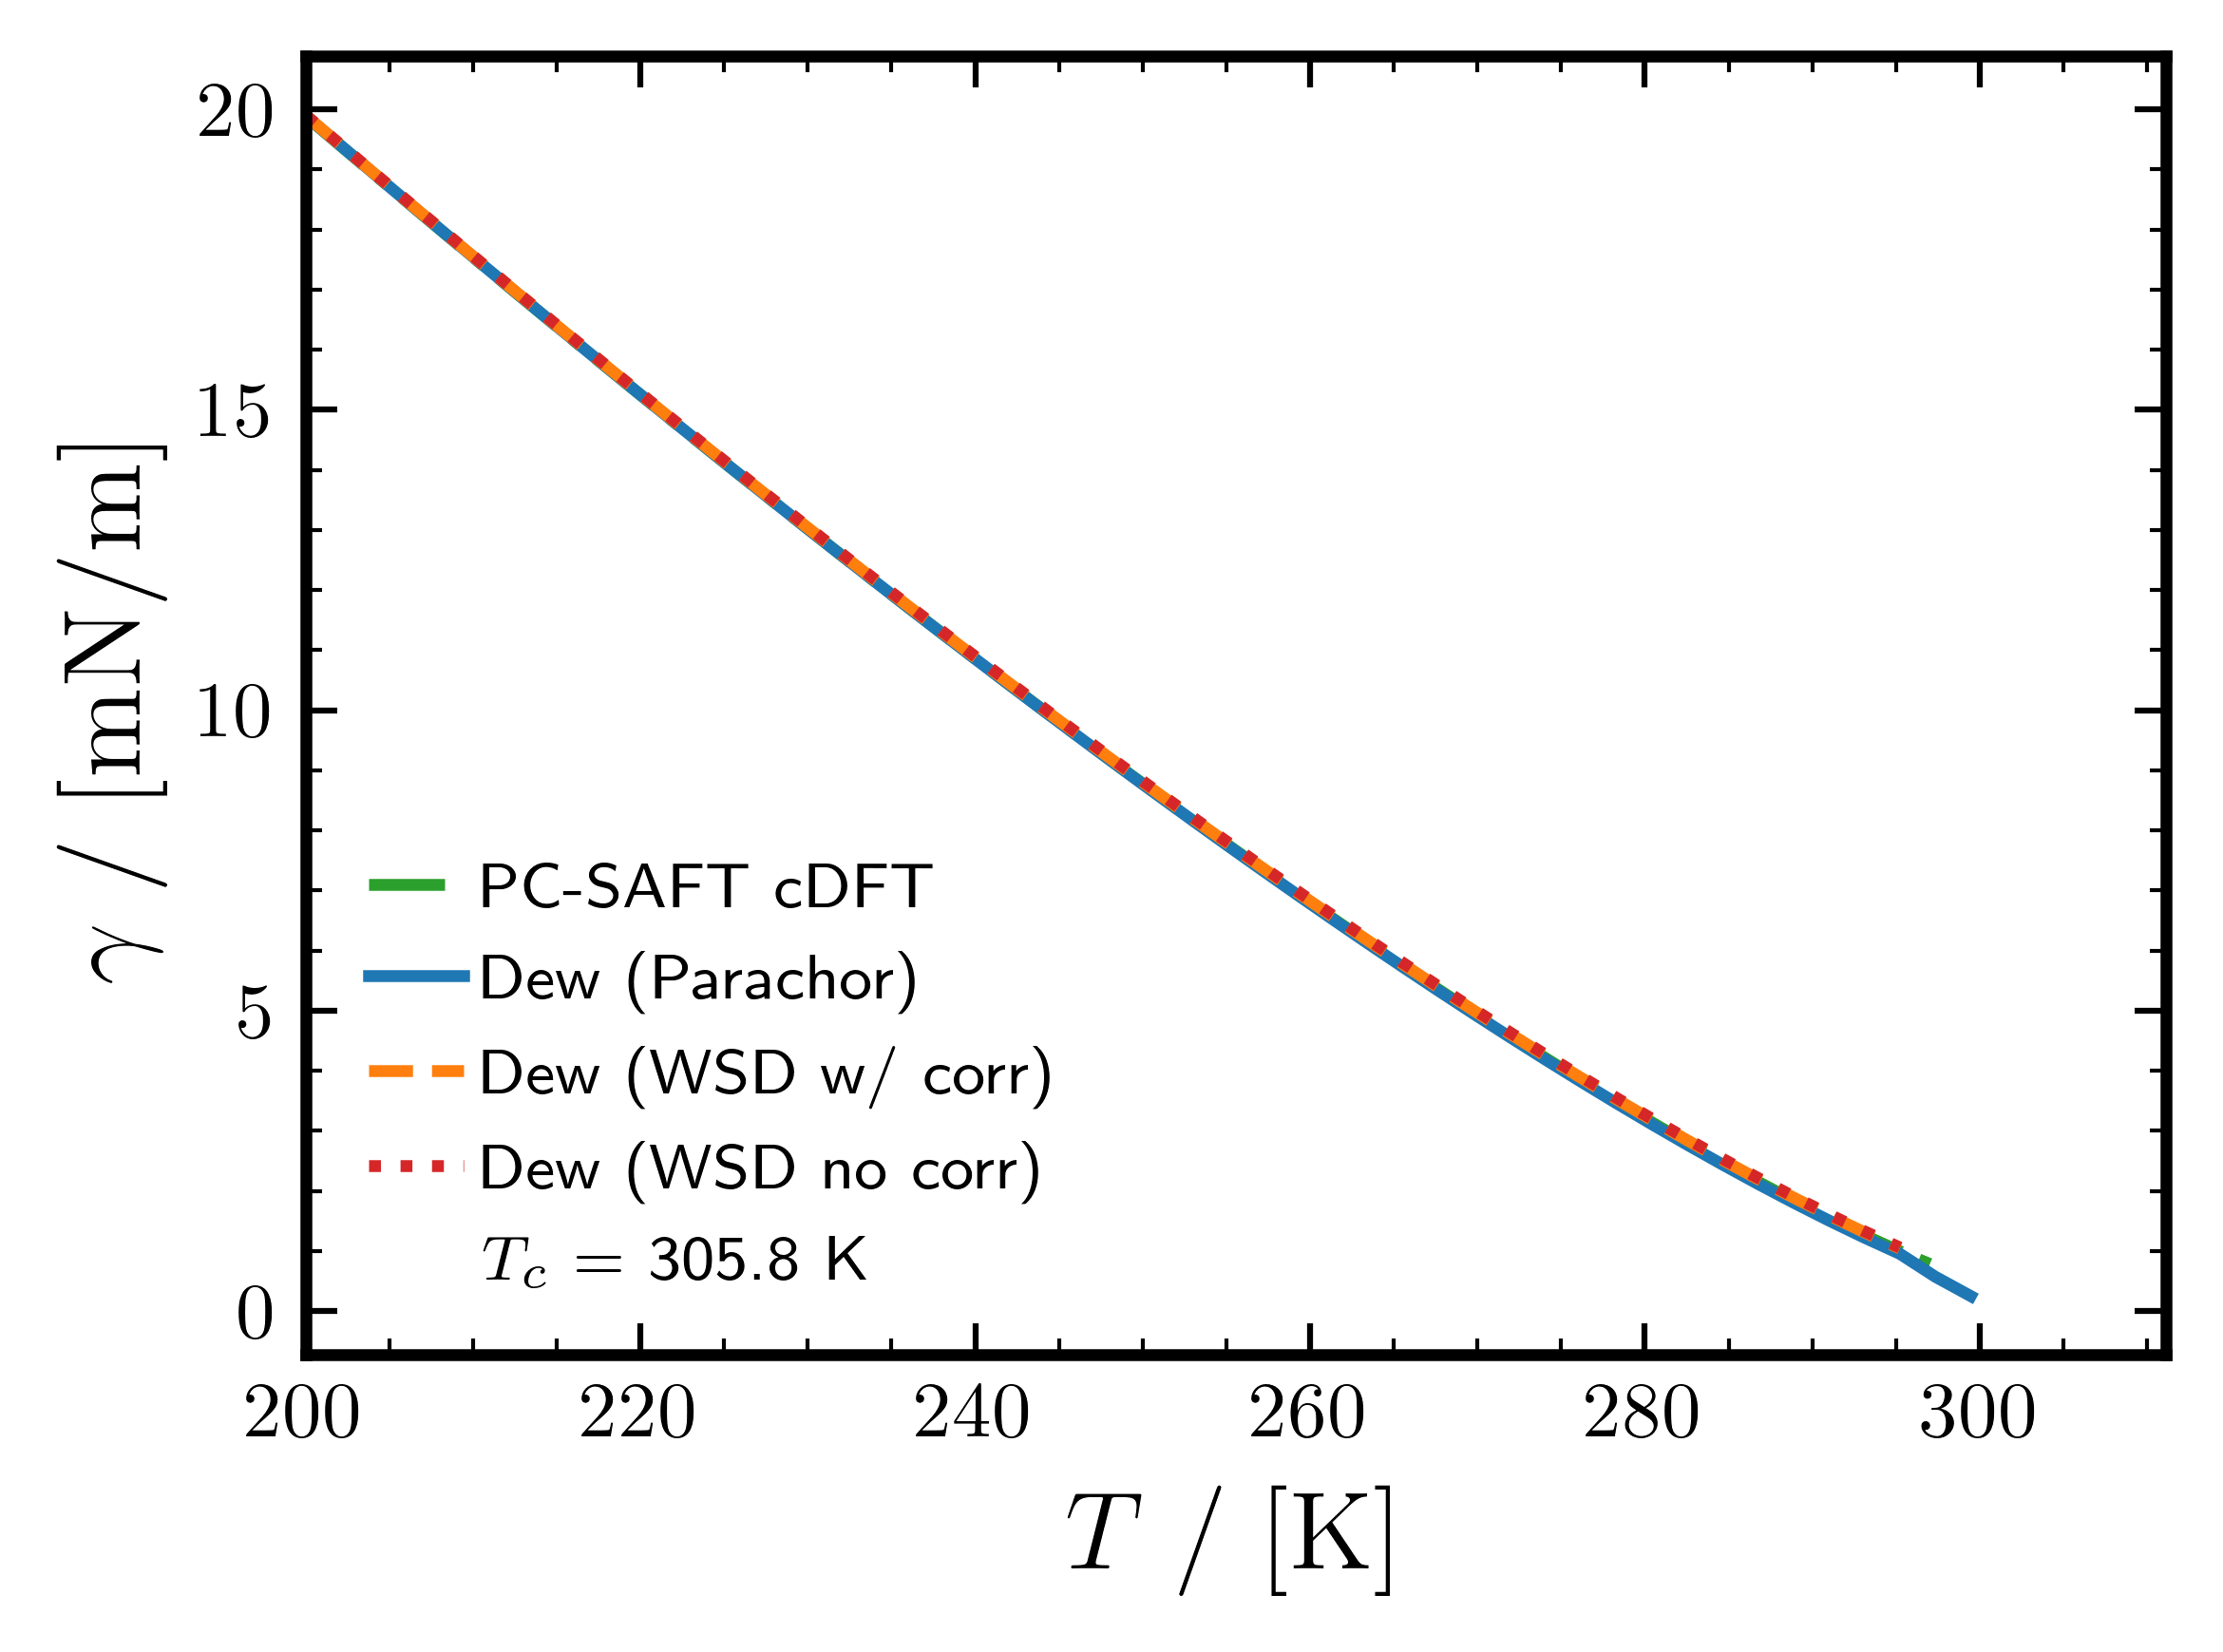

Dew IFT plot saved to CSV_combined/dew_IFT_vs_T.png


In [10]:
# --- Dew IFT vs Temperature (all methods) ---

fig, ax = ps.plot_init()

# PC-SAFT cDFT (planar interface)
if not df_cDFT_dew.empty:
    ax.plot(df_cDFT_dew["temperature"], df_cDFT_dew["gamma"],
            label="PC-SAFT cDFT", linestyle="-.", color="C2")

# Parachor
if not df_dew_para.empty:
    ax.plot(df_dew_para["T"], df_dew_para["gamma_parachor"],
            "-", label="Dew (Parachor)", color="C0")

# WSD
if not df_dew_wsd.empty:
    ax.plot(df_dew_wsd["T"], df_dew_wsd["gamma_wsd_corrected"],
            "--", label="Dew (WSD w/ corr)", color="C1")
    ax.plot(df_dew_wsd["T"], df_dew_wsd["gamma_wsd"],
            ":", label="Dew (WSD no corr)", color="C3")

ax.axvline(Tc_K, color="w", linestyle=":", label=f"$T_c$ = {Tc_K:.1f} K")
ax.set_xlabel(r"$T \; / \; [\mathrm{K}]$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"$\gamma \; / \; [\mathrm{mN/m}]$", fontsize=ps.label_fontsize)
ax.set_xlim(left=200)
ax.minorticks_on()
ps.style_legend(ax, fontsize=ps.legend_fontsize, loc="best", framealpha=0)
plt.tight_layout()
plt.savefig(f"{CSV_FOLDER}/dew_IFT_vs_T.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{CSV_FOLDER}/dew_IFT_vs_T.pdf", bbox_inches="tight")
plt.show()
print(f"Dew IFT plot saved to {CSV_FOLDER}/dew_IFT_vs_T.png")

In [ ]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")